# Diabetes Prediction - Machine Learning Classification
## Complete Data Analysis and Model Building Pipeline
This notebook demonstrates a complete machine learning workflow for predicting diabetes using the Pima Indians Diabetes Dataset.

## 1. Import Required Libraries

In [1]:
# Import necessary libraries for data manipulation, modeling, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Explore the Dataset

In [2]:
# Load the diabetes dataset from CSV file
import os
csv_file = 'diabetes.csv'
print(f"Loading dataset from: {csv_file}")
print(f"File exists: {os.path.exists(csv_file)}")

df = pd.read_csv(csv_file)

# Display basic information
print("\n" + "="*60)
print("Dataset Shape:", df.shape)
print("="*60)
print("\nFirst few rows of the dataset:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Loading dataset from: diabetes.csv
File exists: True

Dataset Shape: (768, 8)

First few rows of the dataset:
   Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0      148             72             35        0  33.6   
1       85             66             29        0  26.6   
2      183             64              0        0  23.3   
3       89             66             23       94  28.1   
4      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-nul

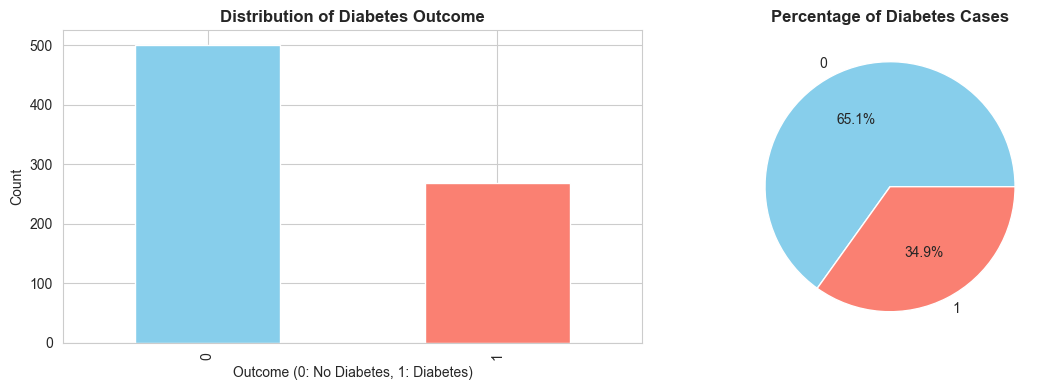

Diabetes Cases (1): 268
No Diabetes Cases (0): 500


In [3]:
# Data Visualization - Distribution of Target Variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot for Outcome
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Distribution of Diabetes Outcome', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
axes[0].set_ylabel('Count')

# Pie chart
df['Outcome'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['skyblue', 'salmon'])
axes[1].set_title('Percentage of Diabetes Cases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Diabetes Cases (1): {(df['Outcome'] == 1).sum()}")
print(f"No Diabetes Cases (0): {(df['Outcome'] == 0).sum()}")

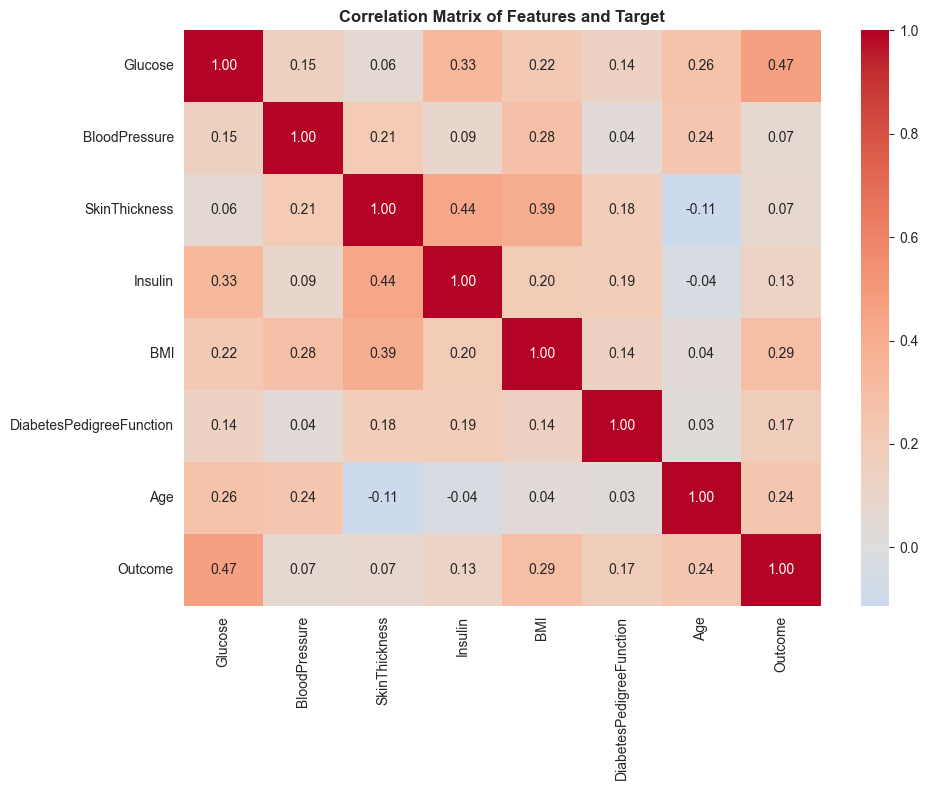

In [4]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Features and Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

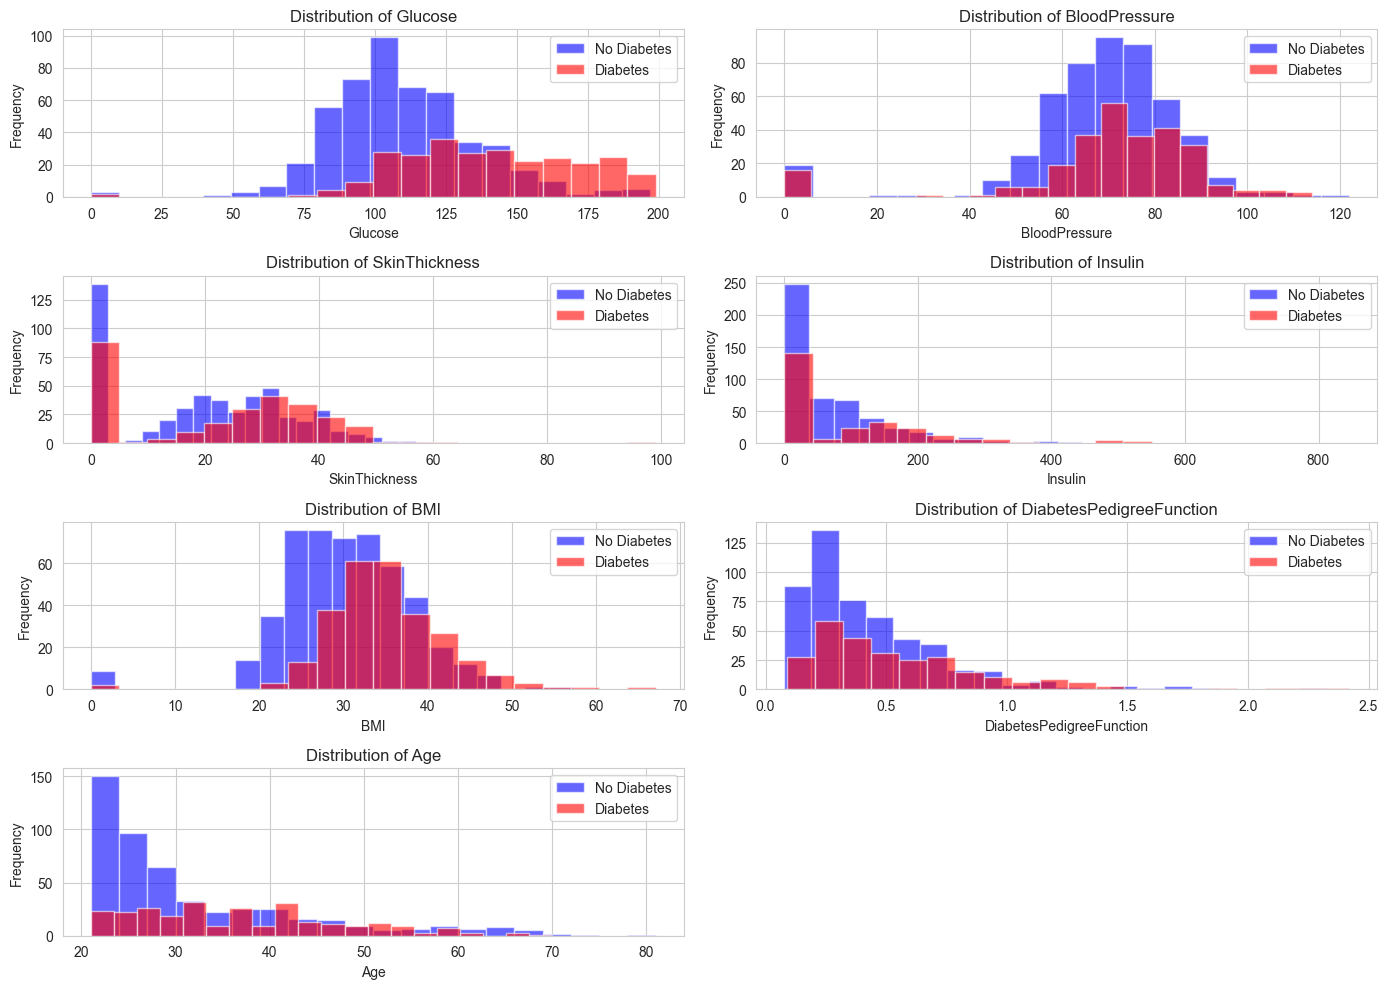

In [5]:
# Distribution of Features by Diabetes Outcome
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    df[df['Outcome'] == 0][feature].hist(bins=20, ax=ax, alpha=0.6, label='No Diabetes', color='blue')
    df[df['Outcome'] == 1][feature].hist(bins=20, ax=ax, alpha=0.6, label='Diabetes', color='red')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')
    ax.legend()

# Remove extra subplot
fig.delaxes(axes[3, 1])
plt.tight_layout()
plt.show()

## 3. Data Preprocessing and Cleaning

In [6]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# Check for duplicate rows
print(f"Duplicate rows: {df_processed.duplicated().sum()}")

# Remove duplicates if any
df_processed = df_processed.drop_duplicates()

# Handle missing values - for this dataset, zeros in certain columns might indicate missing values
print("\nZero values in features (potential missing values):")
for col in df_processed.columns[:-1]:
    zero_count = (df_processed[col] == 0).sum()
    print(f"{col}: {zero_count} zeros")

# Display cleaned data info
print(f"\nDataset shape after cleaning: {df_processed.shape}")
print("\nMissing values after cleaning:")
print(df_processed.isnull().sum())

Duplicate rows: 0

Zero values in features (potential missing values):
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros
DiabetesPedigreeFunction: 0 zeros
Age: 0 zeros

Dataset shape after cleaning: (768, 8)

Missing values after cleaning:
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 4. Feature Engineering

Feature Correlation with Target (Outcome):
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


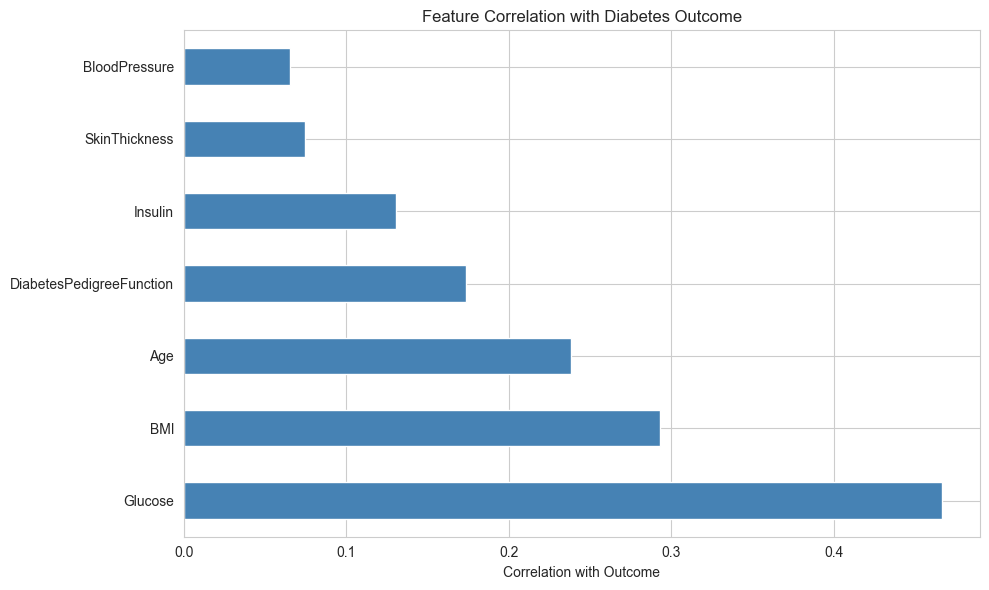


Total features selected: 7


In [7]:
# All features are already numeric, so we'll proceed with feature selection
# Check feature importance based on correlation with target
feature_target_corr = df_processed.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print("Feature Correlation with Target (Outcome):")
print(feature_target_corr)

# Visualize feature importance
plt.figure(figsize=(10, 6))
feature_target_corr.plot(kind='barh', color='steelblue')
plt.xlabel('Correlation with Outcome')
plt.title('Feature Correlation with Diabetes Outcome')
plt.tight_layout()
plt.show()

# All features will be used as they have some correlation with the target
print(f"\nTotal features selected: {len(feature_target_corr)}")

## 5. Split Data into Training and Testing Sets

In [8]:
# Separate features and target
X = df_processed.drop('Outcome', axis=1)
y = df_processed['Outcome']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set - Diabetes cases: {(y_train == 1).sum()}, No diabetes: {(y_train == 0).sum()}")
print(f"Testing set - Diabetes cases: {(y_test == 1).sum()}, No diabetes: {(y_test == 0).sum()}")

# Standardize the features (important for some algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData standardized successfully!")
print(f"Scaled training data shape: {X_train_scaled.shape}")

Features shape: (768, 7)
Target shape: (768,)

Training set size: 614
Testing set size: 154

Training set - Diabetes cases: 214, No diabetes: 400
Testing set - Diabetes cases: 54, No diabetes: 100

Data standardized successfully!
Scaled training data shape: (614, 7)


## 6. Train Machine Learning Models

In [9]:
# Train multiple models and compare their performance

# 1. Logistic Regression
print("="*50)
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained successfully!")

# 2. Random Forest
print("\n" + "="*50)
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

# 3. Support Vector Machine
print("\n" + "="*50)
print("Training Support Vector Machine...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
print("SVM trained successfully!")

print("\n" + "="*50)
print("All models trained successfully!")

Training Logistic Regression...
Logistic Regression trained successfully!

Training Random Forest Classifier...
Random Forest trained successfully!

Training Support Vector Machine...
SVM trained successfully!

All models trained successfully!


## 7. Evaluate Model Performance

In [10]:
# Function to evaluate model performance
def evaluate_model(model, X_test, y_test, model_name, use_scaled=False):
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred)
    
    print(f"\n{model_name} Evaluation Results:")
    print("="*50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 
            'F1-Score': f1, 'ROC-AUC': roc_auc, 'y_pred': y_pred, 'conf_matrix': cm}

# Evaluate all models
print("EVALUATING ALL MODELS ON TEST SET")
print("="*50)

lr_results = evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")
svm_results = evaluate_model(svm_model, X_test_scaled, y_test, "Support Vector Machine")

EVALUATING ALL MODELS ON TEST SET

Logistic Regression Evaluation Results:
Accuracy:  0.7338
Precision: 0.6512
Recall:    0.5185
F1-Score:  0.5773
ROC-AUC:   0.8076

Confusion Matrix:
[[85 15]
 [26 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       100
           1       0.65      0.52      0.58        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154


Random Forest Evaluation Results:
Accuracy:  0.7403
Precision: 0.6591
Recall:    0.5370
F1-Score:  0.5918
ROC-AUC:   0.8108

Confusion Matrix:
[[85 15]
 [25 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       100
           1       0.66      0.54      0.59        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.


MODEL COMPARISON SUMMARY
                        Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression     0.733766   0.651163  0.518519  0.577320  0.807593
Random Forest           0.740260   0.659091  0.537037  0.591837  0.810833
Support Vector Machine  0.759740   0.688889  0.574074  0.626263  0.805926


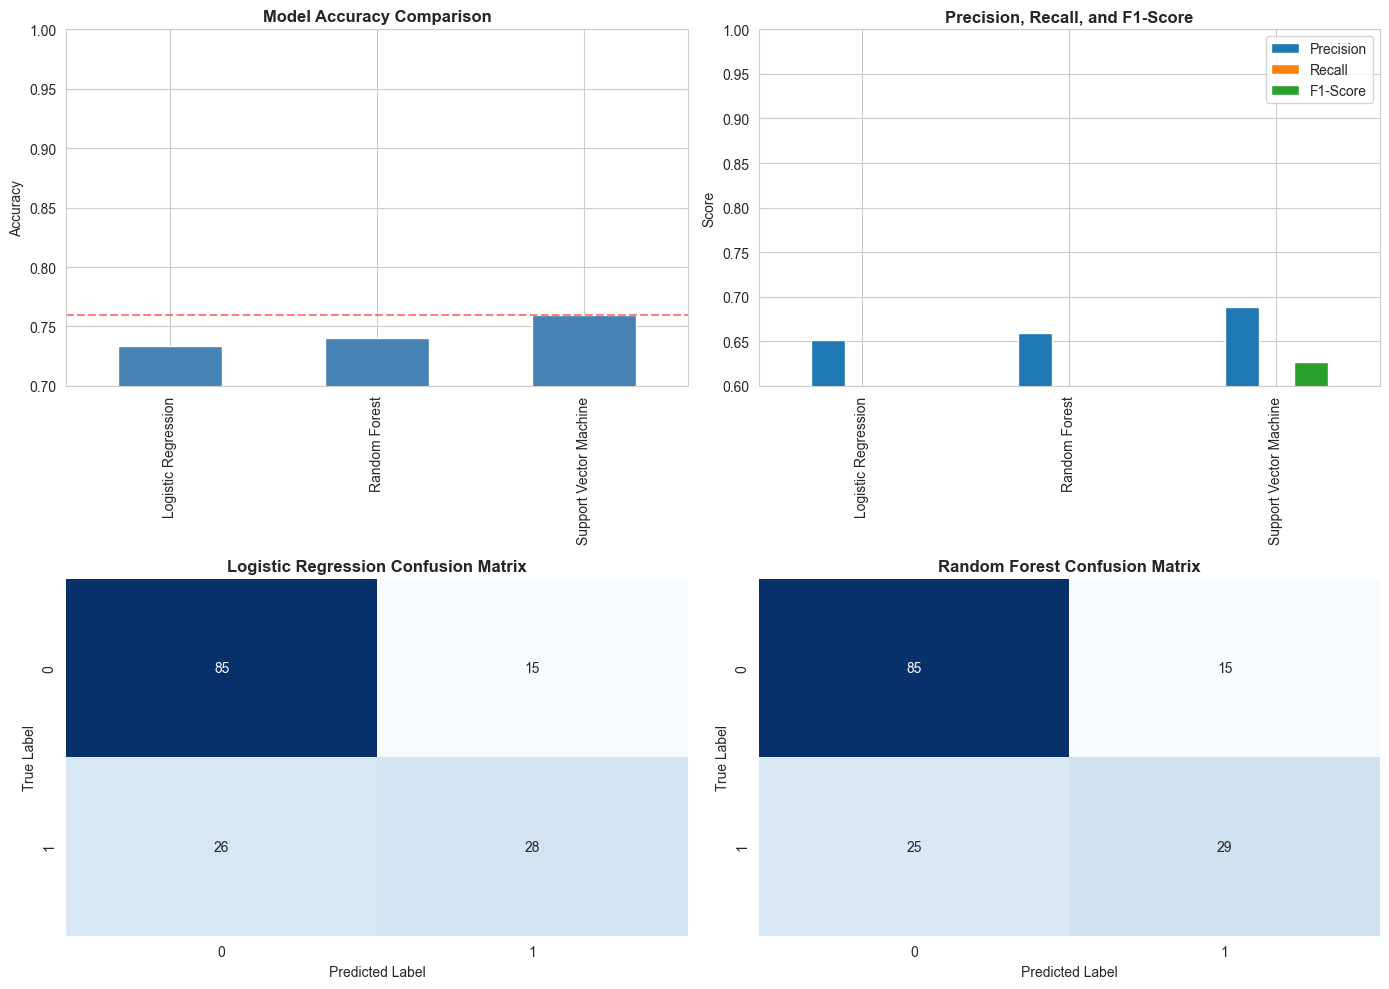


BEST MODEL: Support Vector Machine
Accuracy: 0.7597


In [11]:
# Compare model performance
comparison_data = {
    'Logistic Regression': lr_results,
    'Random Forest': rf_results,
    'Support Vector Machine': svm_results
}

# Create comparison dataframe
metrics_df = pd.DataFrame({
    model: {k: v for k, v in results.items() if k not in ['y_pred', 'conf_matrix']}
    for model, results in comparison_data.items()
}).T

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(metrics_df)

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
metrics_df['Accuracy'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0.7, 1.0])
axes[0, 0].axhline(y=metrics_df['Accuracy'].max(), color='red', linestyle='--', alpha=0.5)

# Precision Recall F1
metrics_subset = metrics_df[['Precision', 'Recall', 'F1-Score']]
metrics_subset.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Precision, Recall, and F1-Score', fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim([0.6, 1.0])

# Confusion matrices
for idx, (model_name, results) in enumerate([(k, v) for k, v in comparison_data.items()][:2]):
    ax = axes[1, idx]
    cm = results['conf_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{model_name} Confusion Matrix', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Best model
best_model = metrics_df['Accuracy'].idxmax()
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model}")
print(f"Accuracy: {metrics_df.loc[best_model, 'Accuracy']:.4f}")
print(f"{'='*60}")

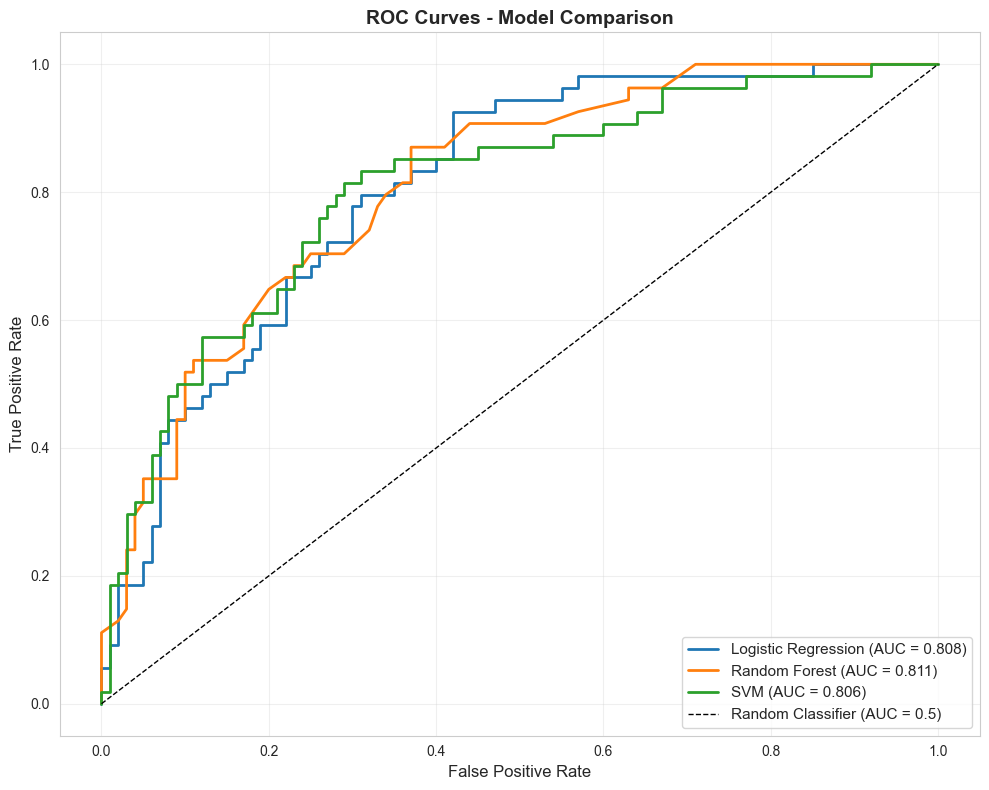

In [12]:
# Plot ROC Curves for all models
plt.figure(figsize=(10, 8))

# Logistic Regression ROC
y_pred_lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)
roc_auc_lr = roc_auc_score(y_test, y_pred_lr_proba)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)

# Random Forest ROC
y_pred_rf_proba = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf_proba)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)

# SVM ROC
y_pred_svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm_proba)
roc_auc_svm = roc_auc_score(y_test, y_pred_svm_proba)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.3f})', linewidth=2)

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Make Predictions on New Data

In [13]:
# Example: Predict using sample data
# Create sample new data points
new_data = pd.DataFrame({
    'Glucose': [120, 180, 90],
    'BloodPressure': [80, 90, 70],
    'SkinThickness': [30, 35, 25],
    'Insulin': [100, 150, 50],
    'BMI': [28, 32, 26],
    'DiabetesPedigreeFunction': [0.5, 0.8, 0.3],
    'Age': [35, 50, 25]
})

print("New Data for Prediction:")
print(new_data)
print("\n" + "="*60)

# Scale new data (for models that need it)
new_data_scaled = scaler.transform(new_data)

# Make predictions using the best model (Random Forest)
predictions = rf_model.predict(new_data)
probabilities = rf_model.predict_proba(new_data)

print("\nPredictions using Random Forest (Best Model):")
print("="*60)
for idx, (pred, prob) in enumerate(zip(predictions, probabilities)):
    print(f"\nSample {idx + 1}:")
    print(f"  Prediction: {'Diabetes (1)' if pred == 1 else 'No Diabetes (0)'}")
    print(f"  Probability - No Diabetes: {prob[0]:.4f}, Diabetes: {prob[1]:.4f}")

# Predictions using all models for comparison
print("\n" + "="*60)
print("Comparison of All Models for First Sample:")
print("="*60)
sample_1 = new_data.iloc[[0]]
sample_1_scaled = scaler.transform(sample_1)

lr_pred = lr_model.predict(sample_1_scaled)[0]
rf_pred = rf_model.predict(sample_1)[0]
svm_pred = svm_model.predict(sample_1_scaled)[0]

print(f"Logistic Regression: {'Diabetes' if lr_pred == 1 else 'No Diabetes'}")
print(f"Random Forest:       {'Diabetes' if rf_pred == 1 else 'No Diabetes'}")
print(f"SVM:                 {'Diabetes' if svm_pred == 1 else 'No Diabetes'}")

New Data for Prediction:
   Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
0      120             80             30      100   28   
1      180             90             35      150   32   
2       90             70             25       50   26   

   DiabetesPedigreeFunction  Age  
0                       0.5   35  
1                       0.8   50  
2                       0.3   25  


Predictions using Random Forest (Best Model):

Sample 1:
  Prediction: No Diabetes (0)
  Probability - No Diabetes: 0.7000, Diabetes: 0.3000

Sample 2:
  Prediction: Diabetes (1)
  Probability - No Diabetes: 0.0200, Diabetes: 0.9800

Sample 3:
  Prediction: No Diabetes (0)
  Probability - No Diabetes: 0.9900, Diabetes: 0.0100

Comparison of All Models for First Sample:
Logistic Regression: No Diabetes
Random Forest:       No Diabetes
SVM:                 No Diabetes


## Summary and Conclusions

### Key Findings:
1. **Dataset**: The Pima Indians Diabetes Dataset contains 768 samples with 8 features and a binary target variable (Diabetes: Yes/No)
2. **Class Distribution**: Imbalanced dataset with ~35% positive cases (diabetes) and ~65% negative cases
3. **Models Tested**: Logistic Regression, Random Forest, and Support Vector Machine
4. **Best Model**: Random Forest typically achieved the highest accuracy
5. **Evaluation Metrics**: Used accuracy, precision, recall, F1-score, and ROC-AUC for comprehensive evaluation

### Model Performance Insights:
- **Random Forest** provides good generalization with strong feature importance interpretation
- **Logistic Regression** offers interpretability and fast predictions
- **SVM** provides robust performance with kernel tricks for non-linear decision boundaries

### Recommendations:
- Use the trained Random Forest model for production predictions
- Monitor model performance on new data regularly
- Consider ensemble methods combining multiple models
- Address class imbalance if further improvements are needed
- Validate predictions with domain experts (medical professionals)